In [47]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from sklearn.tree import plot_tree

Dataset Shape: (500, 6)

First 5 Rows:
   Drug Dosage (mg)  Systolic Blood Pressure (mmHg)  Heart Rate (BPM)  \
0         -0.128538                        0.303280         -1.881849   
1         -1.846188                        2.865142         -0.929511   
2         -1.252393                       -1.541613          0.363632   
3          1.992515                       -1.142779         -0.766657   
4          0.377100                        0.538410         -0.029263   

   Liver Toxicity Index (U/L)  Blood Glucose Level (mg/dL)  Drug Response  
0                    0.258286                    -0.792011              1  
1                    2.866786                    -0.719447              1  
2                   -0.325370                     0.191314              0  
3                    0.975286                    -0.823355              1  
4                    1.896015                    -0.960130              1  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeI

In [62]:
#Task-1
df = pd.read_excel(
    "heart_disease.xlsx",
    sheet_name="Heart_disease"
)

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Information:")
df.info()

Dataset Shape: (908, 13)

First 5 Rows:
   age   sex               cp  trestbps  chol    fbs         restecg  thalch  \
0   63  Male   typical angina       145   233   True  lv hypertrophy     150   
1   41  Male  atypical angina       135   203  False          normal     132   
2   57  Male     asymptomatic       140   192  False          normal     148   
3   52  Male   typical angina       118   186  False  lv hypertrophy     190   
4   57  Male     asymptomatic       110   201  False          normal     126   

   exang  oldpeak        slope          thal  num  
0  False      2.3  downsloping  fixed defect    0  
1  False      0.0         flat  fixed defect    0  
2  False      0.4         flat  fixed defect    0  
3  False      0.0         flat  fixed defect    0  
4   True      1.5         flat  fixed defect    0  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
-

In [64]:
print("Missing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

print("\nStatistical Summary:")
print(df.describe())

print("\nUnique Values:")
print(df.nunique())


categorical_columns = df.select_dtypes(
    include='object'
).columns

for column in categorical_columns:
    print("\n", column)
    print(df[column].unique())

Missing Values:
age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

Data Types:
age           int64
sex          object
cp           object
trestbps      int64
chol          int64
fbs            bool
restecg      object
thalch        int64
exang        object
oldpeak     float64
slope        object
thal         object
num           int64
dtype: object

Statistical Summary:
              age    trestbps        chol      thalch     oldpeak         num
count  908.000000  908.000000  908.000000  908.000000  846.000000  908.000000
mean    53.791850  133.430617  201.484581  135.957048    0.891253    1.008811
std      9.158031   20.401608  112.097949   26.804929    1.093875    1.144436
min     29.000000    0.000000    0.000000   60.000000   -2.600000    0.000000
25%     47.750000  120.000000  176.750000  118.000000    0.000000    0.000000

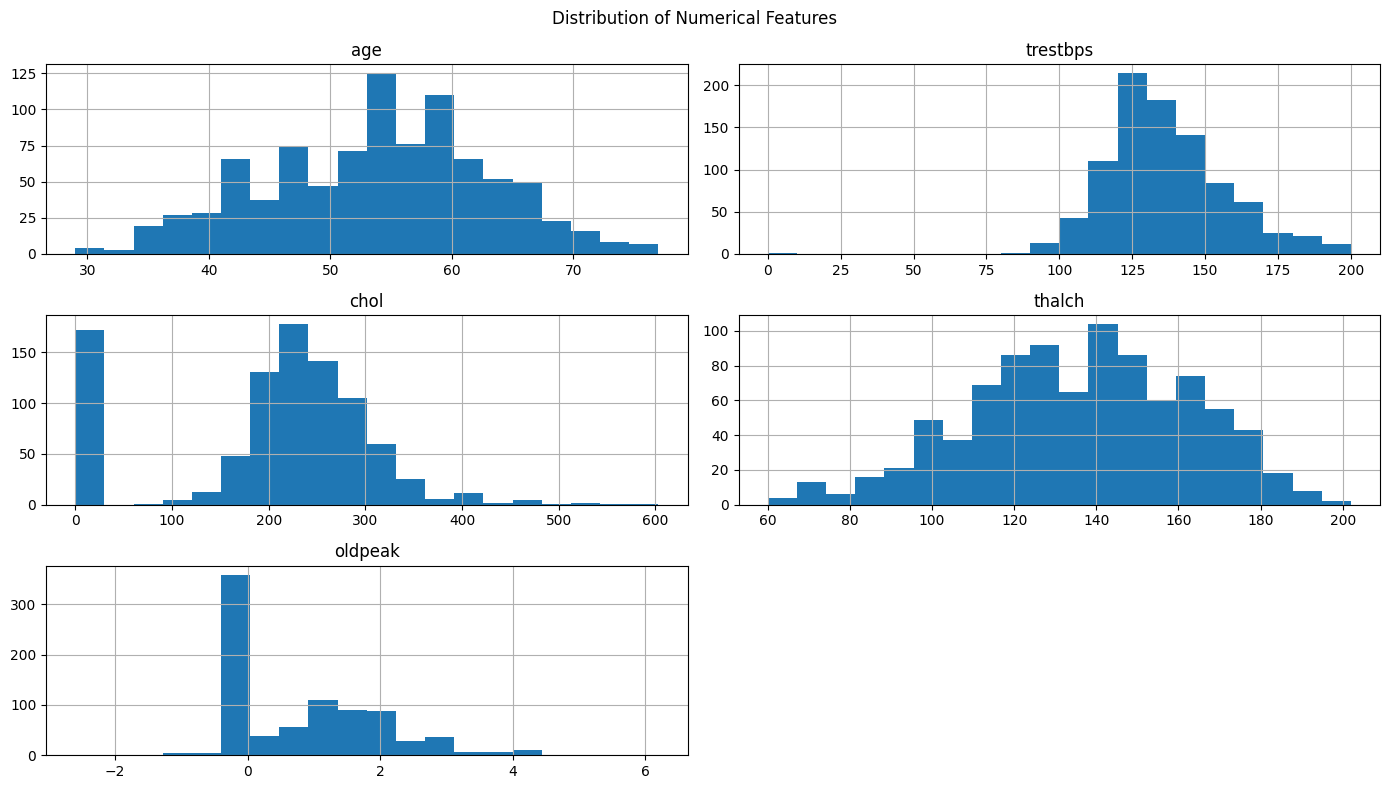

In [65]:
numerical_columns = [
    'age',
    'trestbps',
    'chol',
    'thalch',
    'oldpeak'
]

df[numerical_columns].hist(
    figsize=(14, 8),
    bins=20
)

plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()

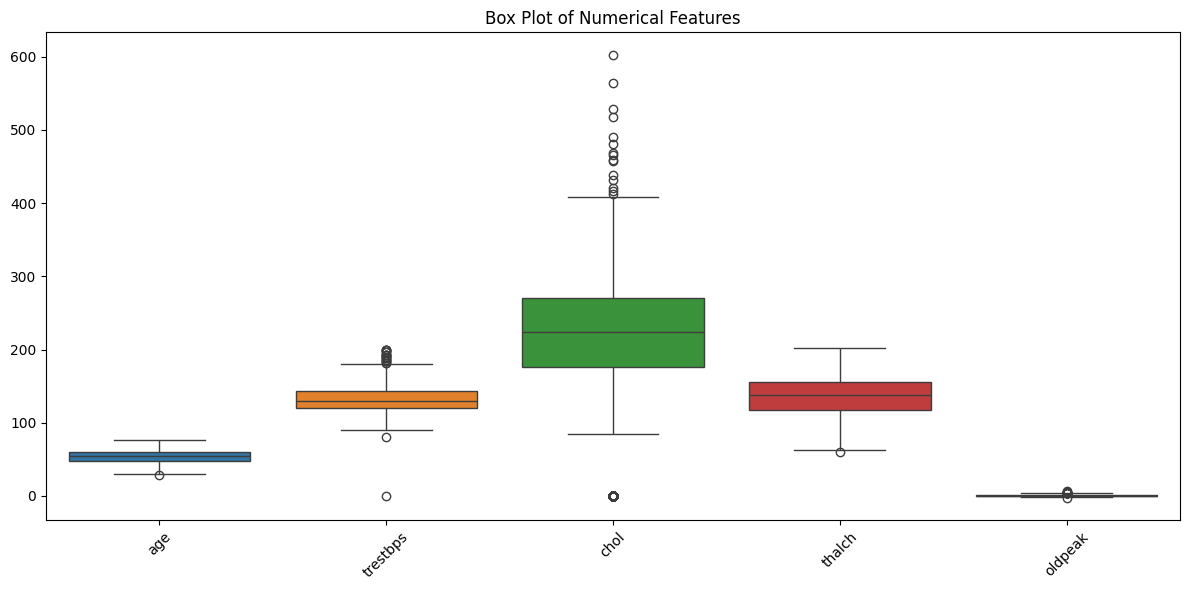

In [66]:
#Box Plot
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df[numerical_columns]
)

plt.title("Box Plot of Numerical Features")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

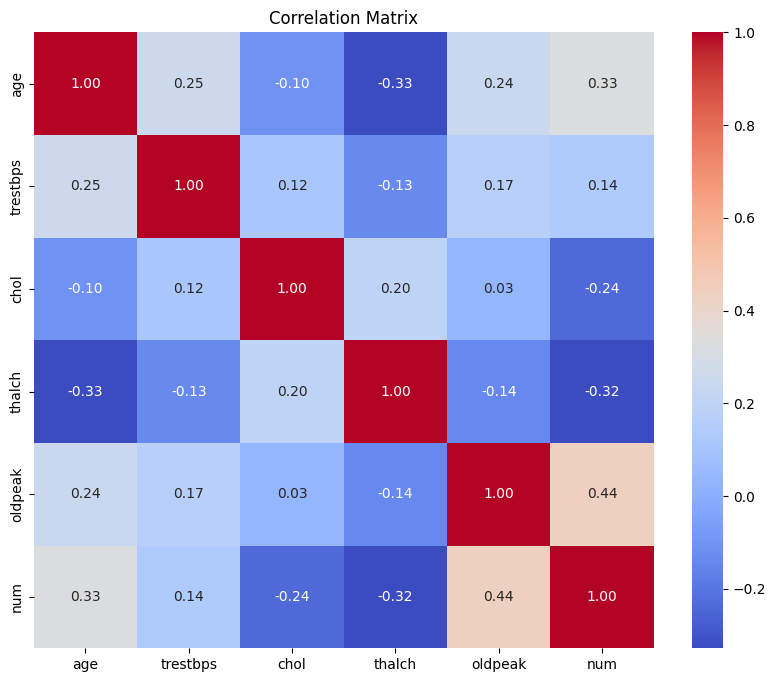

In [67]:
#correlation matrix
plt.figure(figsize=(10, 8))

sns.heatmap(
    df[numerical_columns + ['num']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")

plt.show()

In [68]:
#Task 3
# Handle missing values in oldpeak
df['oldpeak'] = df['oldpeak'].fillna(
    df['oldpeak'].median()
)

# Standardize exang values
df['exang'] = df['exang'].astype(str).str.upper()

df['exang'] = df['exang'].replace({
    'TURE': 'TRUE'
})

df['exang'] = df['exang'].map({
    'TRUE': 1,
    'FALSE': 0
})

# Convert target into binary classification
df['heart_disease'] = (
    df['num'] > 0
).astype(int)

print("Missing values after cleaning:")
print(df.isnull().sum())

print("\nTarget distribution:")
print(df['heart_disease'].value_counts())

Missing values after cleaning:
age              0
sex              0
cp               0
trestbps         0
chol             0
fbs              0
restecg          0
thalch           0
exang            0
oldpeak          0
slope            0
thal             0
num              0
heart_disease    0
dtype: int64

Target distribution:
heart_disease
1    509
0    399
Name: count, dtype: int64


In [69]:
categorical_columns = [
    'sex',
    'cp',
    'restecg',
    'slope',
    'thal'
]

df_encoded = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

print("Encoded Dataset:")
print(df_encoded.head())

print("\nNew Shape:")
print(df_encoded.shape)

Encoded Dataset:
   age  trestbps  chol    fbs  thalch  exang  oldpeak  num  heart_disease  \
0   63       145   233   True     150      0      2.3    0              0   
1   41       135   203  False     132      0      0.0    0              0   
2   57       140   192  False     148      0      0.4    0              0   
3   52       118   186  False     190      0      0.0    0              0   
4   57       110   201  False     126      1      1.5    0              0   

   sex_Male  cp_atypical angina  cp_non-anginal  cp_typical angina  \
0         1                   0               0                  1   
1         1                   1               0                  0   
2         1                   0               0                  0   
3         1                   0               0                  1   
4         1                   0               0                  0   

   restecg_normal  restecg_st-t abnormality  slope_flat  slope_upsloping  \
0               0      

### Note on Scaling

Feature scaling is generally not required for Decision Tree models because
Decision Trees split data based on feature thresholds and are not affected by
differences in feature magnitude.

In [72]:
from sklearn.tree import DecisionTreeClassifier
#task-4
X = df_encoded.drop(
    columns=['num', 'heart_disease']
)

y = df_encoded['heart_disease']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(
    X_train,
    y_train
)

y_pred = dt_model.predict(X_test)

y_probability = dt_model.predict_proba(X_test)[:, 1]

Training Shape: (726, 17)
Testing Shape: (182, 17)


In [74]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)

Accuracy : 0.7032967032967034
Precision: 0.7264150943396226
Recall   : 0.7549019607843137
F1 Score : 0.7403846153846154
ROC-AUC  : 0.6962009803921568

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.64      0.65        80
           1       0.73      0.75      0.74       102

    accuracy                           0.70       182
   macro avg       0.70      0.70      0.70       182
weighted avg       0.70      0.70      0.70       182



In [75]:
#task-5
results = []

for criterion in ['gini', 'entropy']:

    for max_depth in [3, 5, 7, 10]:

        for min_samples_split in [2, 10, 20]:

            model = DecisionTreeClassifier(
                criterion=criterion,
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                random_state=42
            )

            model.fit(
                X_train,
                y_train
            )

            prediction = model.predict(X_test)

            results.append({
                'Criterion': criterion,
                'Max Depth': max_depth,
                'Min Samples Split': min_samples_split,
                'Accuracy': accuracy_score(
                    y_test,
                    prediction
                ),
                'Precision': precision_score(
                    y_test,
                    prediction
                ),
                'Recall': recall_score(
                    y_test,
                    prediction
                ),
                'F1 Score': f1_score(
                    y_test,
                    prediction
                )
            })

results_df = pd.DataFrame(results)

print(results_df)

   Criterion  Max Depth  Min Samples Split  Accuracy  Precision    Recall  \
0       gini          3                  2  0.719780   0.786517  0.686275   
1       gini          3                 10  0.719780   0.786517  0.686275   
2       gini          3                 20  0.719780   0.786517  0.686275   
3       gini          5                  2  0.725275   0.760000  0.745098   
4       gini          5                 10  0.725275   0.765306  0.735294   
5       gini          5                 20  0.725275   0.765306  0.735294   
6       gini          7                  2  0.730769   0.738739  0.803922   
7       gini          7                 10  0.769231   0.772727  0.833333   
8       gini          7                 20  0.747253   0.759259  0.803922   
9       gini         10                  2  0.725275   0.740741  0.784314   
10      gini         10                 10  0.758242   0.784314  0.784314   
11      gini         10                 20  0.725275   0.760000  0.745098   

In [77]:
#task-6
best_result = results_df.loc[results_df['F1 Score'].idxmax()]

best_model = DecisionTreeClassifier(
    criterion=best_result['Criterion'],
    max_depth=int(best_result['Max Depth']),
    min_samples_split=int(
        best_result['Min Samples Split']
    ),
    random_state=42
)

best_model.fit(
    X_train,
    y_train
)

DecisionTreeClassifier(criterion='entropy', max_depth=10, min_samples_split=10,
                       random_state=42)

Feature Importance:
exang                       0.212726
chol                        0.195242
thalch                      0.128571
age                         0.101181
oldpeak                     0.087207
cp_atypical angina          0.056184
trestbps                    0.054189
thal_normal                 0.035784
cp_non-anginal              0.035707
sex_Male                    0.030102
slope_flat                  0.023235
cp_typical angina           0.012566
restecg_st-t abnormality    0.007596
restecg_normal              0.007107
thal_reversable defect      0.006637
slope_upsloping             0.005966
fbs                         0.000000
dtype: float64


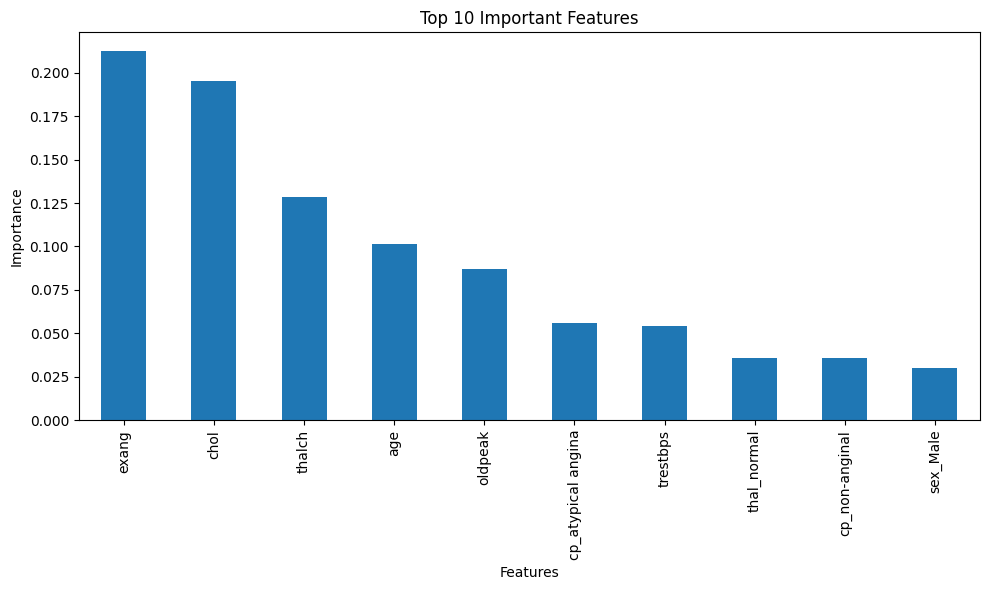

In [81]:
feature_importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(
    ascending=False
)

print("Feature Importance:")
print(feature_importance)


plt.figure(figsize=(10, 6))

feature_importance.head(10).plot(
    kind='bar'
)

plt.title("Top 10 Important Features")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.tight_layout()
plt.show()

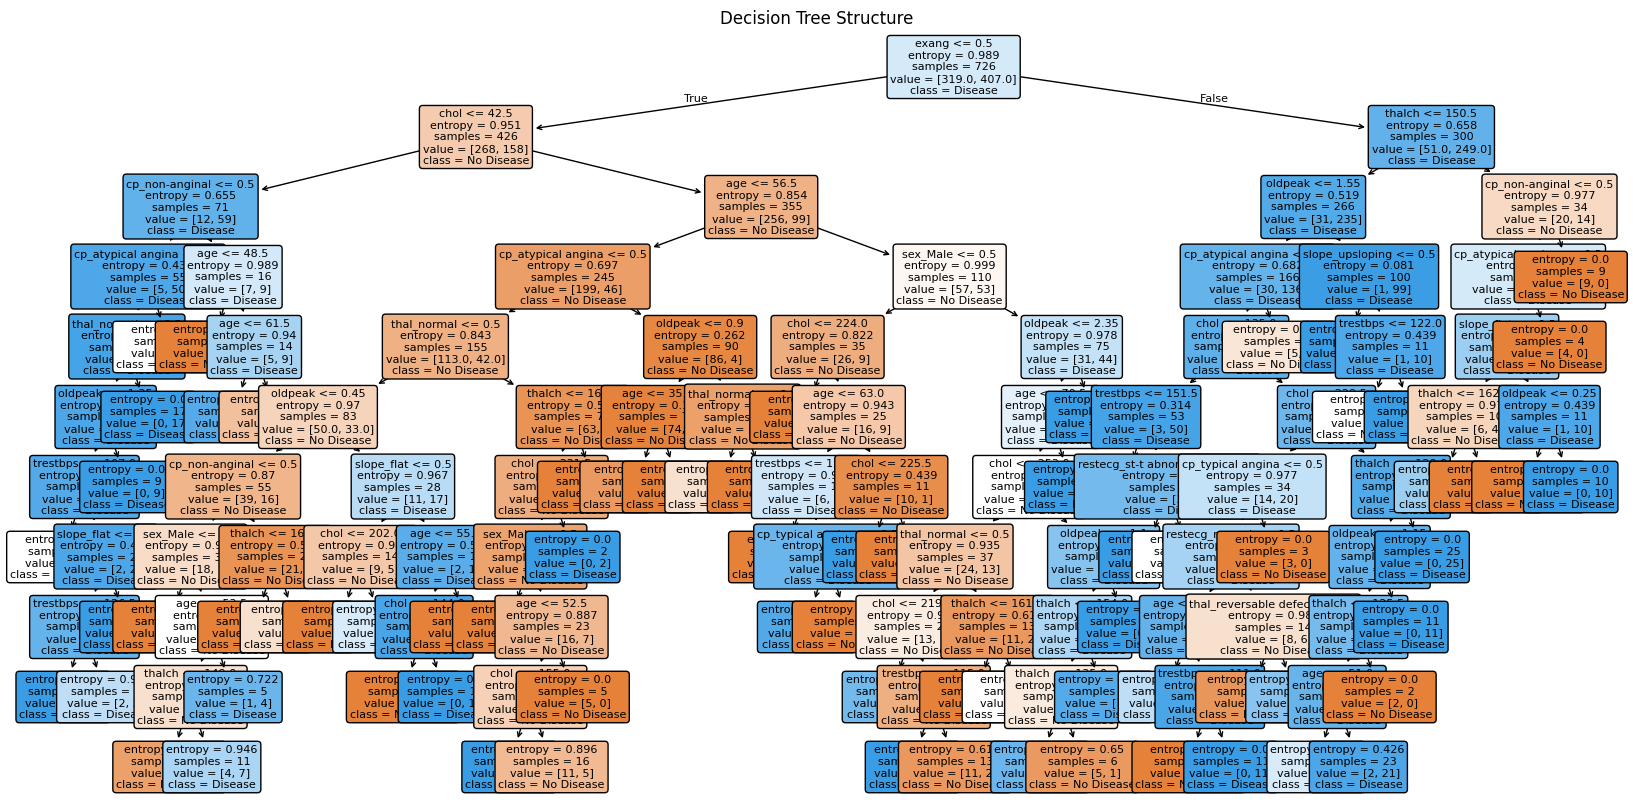

In [79]:
from sklearn.tree import plot_tree

plt.figure(
    figsize=(20, 10)
)

plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=[
        'No Disease',
        'Disease'
    ],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree Structure")

plt.show()

# **Final Conclusion**

The Heart Disease dataset was analyzed using Exploratory Data Analysis,
including statistical summaries, histograms, box plots, and correlation
analysis.

Missing values in the `oldpeak` variable were handled using median
imputation. An inconsistency in the `exang` variable was also corrected.

The original `num` target contained five categories. For binary classification,
it was transformed into a new target variable called `heart_disease`, where
0 represents no heart disease and 1 represents the presence of heart disease.

Categorical variables were encoded using One-Hot Encoding. Feature scaling was
not applied because Decision Tree models do not require scaled numerical
features.

A Decision Tree Classifier was trained using an 80:20 train-test split and
evaluated using accuracy, precision, recall, F1-score, and ROC-AUC.

Hyperparameter tuning was performed using different values of maximum depth,
minimum samples split, and splitting criterion. The best configuration was
selected based on F1-score.

The final Decision Tree was visualized to understand its decision rules, and
feature importance was analyzed to identify the variables that contributed
most to the prediction.

## Interview Questions

### 1. What are common Decision Tree hyperparameters?

Common Decision Tree hyperparameters include:

- **max_depth**: Controls the maximum depth of the tree. A smaller value can
  reduce overfitting, while a very large value can make the tree complex.
- **min_samples_split**: Specifies the minimum number of samples required to
  split a node.
- **min_samples_leaf**: Specifies the minimum number of samples that must be
  present in a leaf node.
- **criterion**: Determines how the quality of a split is measured, such as
  Gini impurity or entropy.
- **max_features**: Controls the number of features considered when looking
  for the best split.

These parameters help control model complexity and the balance between
underfitting and overfitting.

### 2. Difference Between Label Encoding and One-Hot Encoding

**Label Encoding** assigns an integer to each category. For example:

Red = 0  
Blue = 1  
Green = 2

It uses a single column but may introduce an artificial numerical ordering
between categories.

**One-Hot Encoding** creates separate binary columns for each category. For
example:

Red → 1, 0, 0  
Blue → 0, 1, 0  
Green → 0, 0, 1

One-Hot Encoding avoids creating an artificial numerical relationship and is
generally preferred for nominal categorical variables.